# Predicting the MathScore

In [1]:
!pip install xgboost
!pip install shap

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import shap

## Data cleaning

In [3]:
X = pd.read_csv('X_train.csv')
y = pd.read_csv('y_train.csv')

In [14]:
df = X.copy()
y_train = y.copy()

In [ ]:
df = pd.read_csv('train.csv', nrows=1000)

In [15]:
# On drop les colonnes en lien avec les notes/temps de réponse des maths sauf math_q1_total_timing qui n'est pas vide dans le jeu test

math_cols = [col for col in df.columns if col.startswith("math_q") and col != "math_q1_total_timing"]
df = df.drop(columns=math_cols)

# On retire les colonnes d'identifiant
df = df.drop(columns=['Unnamed: 0'])
y_train = y_train.drop(columns=['Unnamed: 0'])

In [16]:
# X on convertit les objects en catégories
obj_cols = df.select_dtypes(include="object").columns

for col in obj_cols:
    df[col] = df[col].astype("category")

In [17]:
cols = ["Year","CNTRYID","CNTSCHID","CNTSTUID","CYC","NatCen","STRATUM","SUBNATIO","OECD","ADMINMODE","LANGTEST_QQQ","LANGTEST_COG","LANGTEST_PAQ",
        "Option_CT","Option_FL", "Option_ICTQ","Option_WBQ","Option_PQ","Option_TQ","Option_UH","BOOKID","COBN_S","PA167","WB153","WB154","WB155","WB160",
        "WB162","WB168","WB177","WB178","ST038","ST036", "IC170","IC173", "IC176","IC177","IC175","IC183","IC182","IC180"]

df = df.drop(columns=cols, errors='ignore')

In [18]:
X_train = df


## Training the model

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [13]:
xgb = XGBRegressor(
    n_estimators=2500,
    learning_rate=0.01894113546106644,
    tree_method="hist",
    enable_categorical=True,
    max_depth=9,
    subsample=0.7526442230516279,
    colsample_bytree=0.6054226090846563,
    objective='reg:squarederror',
    random_state=42,
    gamma = 0.12,
    min_child_weight = 3,
    reg_alpha = 0.3080607918523892,
    reg_lambda = 2.627620691664698
)

xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R² :", r2)
print("RMSE :", rmse)

R² : 0.7874872088432312
RMSE : 56.25975826814958


## Predicting on test DATA

X_jeu_test = pd.read_csv('X_test.csv')

In [71]:
# On drop les colonnes en lien avec les notes/temps de réponse des maths sauf math_q1_total_timing qui n'est pas vide dans le jeu test

math_cols = [col for col in X_jeu_test.columns if col.startswith("math_q") and col != "math_q1_total_timing"]
X_jeu_test = X_jeu_test.drop(columns=math_cols)

In [72]:
# X on convertit les objects en catégories
obj_cols = X_jeu_test.select_dtypes(include="object").columns

for col in obj_cols:
    X_jeu_test[col] = X_jeu_test[col].astype("category")

In [73]:
X_jeu_test = X_jeu_test.drop(columns=cols, errors='ignore')

In [74]:
id_col = X_jeu_test['Unnamed: 0'].copy()
X_jeu_test = X_jeu_test.drop(columns=['Unnamed: 0'])

In [75]:
y_pred = xgb.predict(X_jeu_test)

In [76]:
df_pred = pd.DataFrame({
    "ID": id_col,
    "MathScore": y_pred
})


In [77]:
df_pred.to_csv("predictions.csv", index=False)

## Explanibility

In [18]:
# these columns were choosed based on the feature_importances of the XGBRegressor above

cols_to_keep = [
    'ST250', 'ST253', 'reading_q1_average_score', 'math_q1_total_timing',
    'ST290', 'science_q1_average_score', 'ST127', 'science_q6_average_score',
    'PA195', 'science_q7_average_score', 'reading_q3_average_score',
    'science_q2_average_score', 'science_q5_average_score',
    'science_q4_average_score', 'science_q8_average_score', 'ST255',
    'science_q3_average_score', 'science_q1_total_timing', 'ST163',
    'reading_q2_average_score', 'reading_q7_average_score',
    'reading_q6_average_score', 'reading_q1_total_timing',
    'ST003D03T', 'ST004D01T', 'reading_q5_average_score', 'ST011',
    'ISCEDP', 'ST059', 'science_q9_average_score', 'ST251', 'IC001',
    'reading_q4_average_score', 'EC153', 'science_q3_total_timing'
]

X_train = X.copy()[cols_to_keep]
y_train = y.copy().drop(columns=['Unnamed: 0'])

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [11]:
xgb_shap = XGBRegressor(
    n_estimators=1500,
    learning_rate=0.05,
    tree_method="hist",
    enable_categorical=True,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

xgb_shap.fit(X_train, y_train)
y_pred = xgb_shap.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R² :", r2)
print("RMSE :", rmse)

R² : 0.764147937297821
RMSE : 59.268671240588816


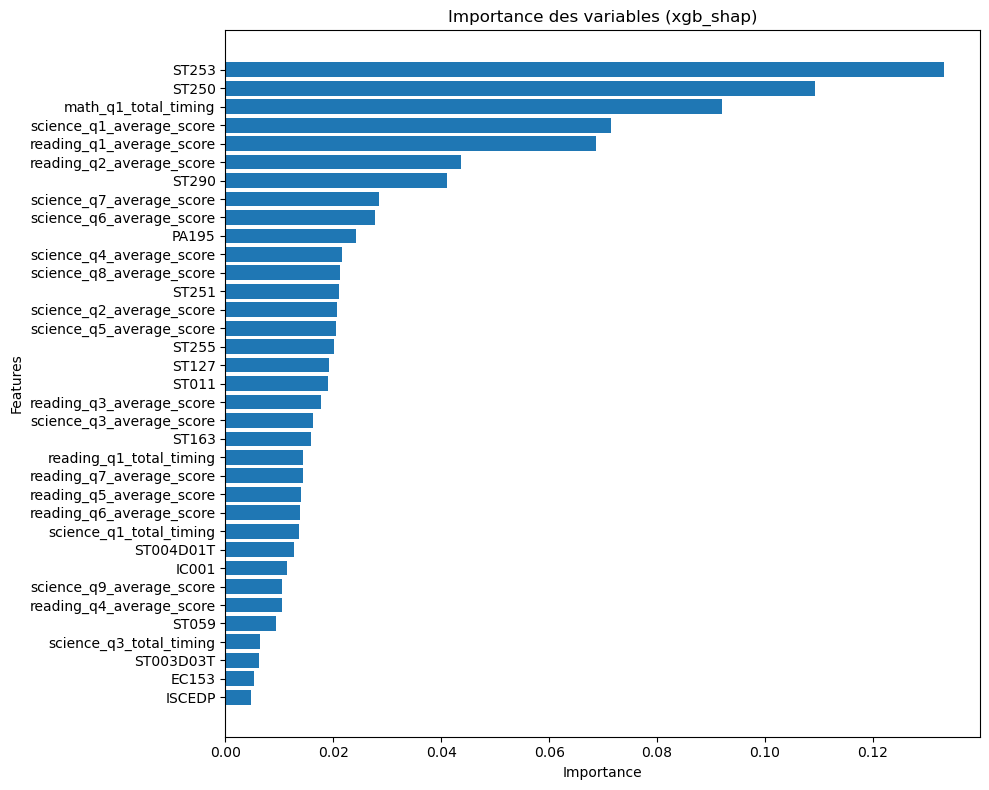

In [16]:
importances = xgb_shap.feature_importances_
feature_names = xgb_shap.feature_names_in_

# Tri décroissant
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 8))
plt.barh(
    [feature_names[i] for i in indices][::-1],
    importances[indices][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Importance des variables (xgb_shap)")
plt.tight_layout()
plt.show()


We can see that 5 features have a lot of importance ST253, ST250, math_q1_total_timing, science_q1_average_score, reading_q1_average_score.
these variables correspond to :  
- ST253 : How many digital devices with screens are present in your home ?
- ST250 : Which of the following resources are available in your home to support your schoolwork: a private space, a computer, educational software, a smartphone with internet, or separate internet access?
- math_q1_total_timing : Time spent on the first question of math
- science_q1_average_score : Score on the first question of science
- reading_q1_average_score : Score on the first question of reading

We can then draw a link beetween math capacities and this four values. It seems that access to digital ressources, capacities in science and reading are strongly linked with the math level of a student.

## Test

In [22]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import pandas as pd

# X_train, y_train existent déjà

# 1) Split pour évaluer la perf finale (train / test)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# 2) Modèle 1 (base model)
model1 = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    tree_method="hist",
    enable_categorical=True,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

# 3) Générer des prédictions out-of-fold sur X_tr
# (important pour éviter le leakage)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_pred = cross_val_predict(
    model1, X_tr, y_tr, cv=kf, method="predict"
)

# 4) Ajouter cette colonne de prédiction au X_tr
X_tr_2 = X_tr.copy()
X_tr_2["model1_pred"] = oof_pred

# 5) Entraîner model1 sur tout X_tr (optionnel, mais logique)
model1.fit(X_tr, y_tr)

# 6) Créer la même feature 'model1_pred' sur X_te (prédictions du model1)
X_te_2 = X_te.copy()
X_te_2["model1_pred"] = model1.predict(X_te)

# 7) Modèle 2 (meta-modèle, peut être XGBoost aussi)
model2 = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    tree_method="hist",
    enable_categorical=True,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

model2.fit(X_tr_2, y_tr)

# 8) Prédictions finales
y_pred = model2.predict(X_te_2)

# 9) R² et MSE
r2 = r2_score(y_te, y_pred)
mse = mean_squared_error(y_te, y_pred)

print("R² :", r2)
print("MSE :", mse)


R² : 0.7854096293449402
MSE : 3196.10400390625


In [28]:
np.sqrt(mse)

56.53409594135427